In [1]:
# System and Utilities
import os
import json
from pathlib import Path
from datetime import datetime
from collections import defaultdict

# Data Manipulation and Geospatial
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import spearmanr, pearsonr

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm

# Machine Learning - Preprocessing and Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    classification_report, 
    roc_auc_score, 
    roc_curve, 
    r2_score
)

# Machine Learning - Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import joblib

# Causal Inference (EconML & CausalML)
from econml.dml import CausalForestDML, LinearDML
from causalml.inference.meta import BaseXClassifier, BaseXRegressor
from causalml.metrics import auuc_score, qini_score

# Explainability
import shap


c:\Users\Somnath_UCI\anaconda3\envs\causalml\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# Define  base directories for both OS types

home = Path.home()
potential_roots = [
    home / "Library/CloudStorage/OneDrive-UCIrvine",      # Mac UCI
    home / "Library/CloudStorage/OneDrive-Personal",     # Mac Personal
    home / "OneDrive - UC Irvine",                       # Windows UCI
    home / "OneDrive",                                   # Windows Personal
]

#  Find the first root that actually exists
location = next((root for root in potential_roots if root.exists()), None)

if location is None:
    raise FileNotFoundError("Could not find OneDrive root directory on this machine.")

print(f"Detected OneDrive at: {location}")

#  Build the rest of the path using the / operator (cross-platform safe)
# Ensure the folder names below EXACTLY match the case in your file explorer
relative_path = Path("BuildingDamagePotential") / "Modellings" / "CalDins_upd_extractions_subset_03.csv"
full_path = location / relative_path

# 4. Final check and load
if full_path.exists():
    df_withoutBalancing = pd.read_csv(full_path)
    print("File loaded successfully!")
else:
    # If it fails, list the folder contents to see if there is a typo
    print(f"❌ File not found at: {full_path}")
    parent_dir = full_path.parent
    if parent_dir.exists():
        print(f"Contents of {parent_dir}:")
        print(os.listdir(parent_dir))
    else:
        print(f"The folder {parent_dir} does not exist.")


Detected OneDrive at: C:\Users\Somnath_UCI\OneDrive - UC Irvine
File loaded successfully!


In [3]:
Data = df_withoutBalancing.copy()
Data.dropna(inplace=True)
Data

,IDs,Aspect,Elevation,Slope,TRI,EVC,EVH,EVT,Damage,WUI_Area,...,tdmean,WD,Tmin,Tmax,VPD,WS10m,Firename,Longitude,Latitude,Damage01
0,1.0,246,76,5,7.937254,352,303,9829,No Damage,0.089125,...,5.3070,240.0,280.799988,296.799988,1.07,7.2,Quail,-122.044465,38.474960,0
1,2.0,277,102,12,17.204651,17,17,7914,Affected (1-9%),0.089121,...,5.3070,240.0,280.799988,296.799988,1.07,7.2,Quail,-122.043252,38.477442,1
2,3.0,281,97,5,6.557438,16,16,7913,No Damage,0.069422,...,5.3070,240.0,280.799988,296.799988,1.07,7.2,Quail,-122.044585,38.479358,0
3,4.0,358,71,14,19.748417,22,22,7296,No Damage,0.078652,...,4.7140,240.0,282.200012,297.200012,1.10,7.4,Quail,-122.015115,38.487313,0
4,5.0,33,102,7,20.322401,17,17,7914,No Damage,0.089100,...,4.7140,240.0,282.200012,297.200012,1.10,7.4,Quail,-122.016122,38.485636,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100223,100226.0,122,59,3,5.385165,16,16,7913,No Damage,0.000000,...,0.6302,20.0,281.500000,293.600006,0.95,1.5,No Fire Name Found,-118.700625,34.033408,0
100224,100227.0,200,57,9,14.422205,222,212,7092,No Damage,0.000000,...,0.6302,20.0,281.500000,293.600006,0.95,1.5,No Fire Name Found,-118.700902,34.033278,0
100225,100228.0,190,60,3,4.690416,16,16,7913,No Damage,0.000000,...,0.6302,20.0,281.500000,293.600006,0.95,1.5,No Fire Name Found,-118.701102,34.033618,0
100226,100229.0,149,5,13,17.635193,25,25,7299,No Damage,0.047628,...,0.6302,20.0,281.500000,293.600006,0.95,1.5,No Fire Name Found,-118.698270,34.032085,0


In [4]:
Data["Aspect"] = Data["Aspect"].astype("float64")
Data["Elevation"] = Data["Elevation"].astype("float64")
Data["Slope"] = Data["Slope"].astype("float64")

In [5]:
# Split the data into x and y 
X = Data.drop(columns=['IDs','Damage','Damage01','Firename',"MinRH","Tmin",'EVC','BTGS',
                       'GrsShr_Area', 'Longitude', 'Latitude', 'BuildYear'])
                                         
                                         #, 'CBFR'  ])
                                      #         , "prcp", "MaxRH",
                                       #          "Srad",'tdmean','WD',"Tmax","VPD",'WS10m'])
#X1 = Data.drop(columns=['IDs','Damage','Damage01' , 'CBFR', 'Firename',"MinRH","Tmin",  'Longitude', 'Latitude', 'EVC','BTGS','GrsShr_Area' ])
                                      #         , "prcp", "MaxRH",
                                       #          "Srad",'tdmean','WD',"Tmax","VPD",'WS10m'])

#X2 = Data.drop(columns=['IDs','Damage','Damage01' , 'CBFR', 'Firename',"MinRH","Tmin",  'Longitude', 'Latitude', "prcp", "MaxRH",  'EVC','BTGS','GrsShr_Area',
                                              #'BuildYear',"Srad",'tdmean','WD',"Tmax","VPD",'WS10m'])

y = Data['Damage01']


In [6]:
Data_p = Data.copy()
#Data_p['BuildYear'] = Data_p['BuildYear'].where(Data_p['BuildYear'] >= 1500, 1500)
Data_p

,IDs,Aspect,Elevation,Slope,TRI,EVC,EVH,EVT,Damage,WUI_Area,...,tdmean,WD,Tmin,Tmax,VPD,WS10m,Firename,Longitude,Latitude,Damage01
0,1.0,246.0,76.0,5.0,7.937254,352,303,9829,No Damage,0.089125,...,5.3070,240.0,280.799988,296.799988,1.07,7.2,Quail,-122.044465,38.474960,0
1,2.0,277.0,102.0,12.0,17.204651,17,17,7914,Affected (1-9%),0.089121,...,5.3070,240.0,280.799988,296.799988,1.07,7.2,Quail,-122.043252,38.477442,1
2,3.0,281.0,97.0,5.0,6.557438,16,16,7913,No Damage,0.069422,...,5.3070,240.0,280.799988,296.799988,1.07,7.2,Quail,-122.044585,38.479358,0
3,4.0,358.0,71.0,14.0,19.748417,22,22,7296,No Damage,0.078652,...,4.7140,240.0,282.200012,297.200012,1.10,7.4,Quail,-122.015115,38.487313,0
4,5.0,33.0,102.0,7.0,20.322401,17,17,7914,No Damage,0.089100,...,4.7140,240.0,282.200012,297.200012,1.10,7.4,Quail,-122.016122,38.485636,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100223,100226.0,122.0,59.0,3.0,5.385165,16,16,7913,No Damage,0.000000,...,0.6302,20.0,281.500000,293.600006,0.95,1.5,No Fire Name Found,-118.700625,34.033408,0
100224,100227.0,200.0,57.0,9.0,14.422205,222,212,7092,No Damage,0.000000,...,0.6302,20.0,281.500000,293.600006,0.95,1.5,No Fire Name Found,-118.700902,34.033278,0
100225,100228.0,190.0,60.0,3.0,4.690416,16,16,7913,No Damage,0.000000,...,0.6302,20.0,281.500000,293.600006,0.95,1.5,No Fire Name Found,-118.701102,34.033618,0
100226,100229.0,149.0,5.0,13.0,17.635193,25,25,7299,No Damage,0.047628,...,0.6302,20.0,281.500000,293.600006,0.95,1.5,No Fire Name Found,-118.698270,34.032085,0


In [7]:
Data_p.columns

Index(['IDs', 'Aspect', 'Elevation', 'Slope', 'TRI', 'EVC', 'EVH', 'EVT',
       'Damage', 'WUI_Area', 'BuildingDensity', 'BTF', 'BTGS', 'Frs_Area',
       'GrsShr_Area', 'RoadLength', 'PFTk9', 'CBFR', 'BuildYear', 'prcp',
       'MaxRH', 'MinRH', 'Srad', 'tdmean', 'WD', 'Tmin', 'Tmax', 'VPD',
       'WS10m', 'Firename', 'Longitude', 'Latitude', 'Damage01'],
      dtype='object')

In [8]:
Firenames = Data_p['Firename'].unique().tolist()
Firenames

['Quail',
 'No Fire Name Found',
 'Elkhorn',
 'Doe',
 'August Complex West',
 'August Complex North',
 'August Complex South',
 'Bear',
 'Castle',
 'Napa',
 'Santa Rosa',
 'Sonoma',
 'St. Helena',
 'Hennessey',
 'Meyers',
 'Walbridge',
 'Carmel',
 'River',
 'CZU Lightning Complex',
 'SCU Lightning Complex',
 'Mendocino Complex',
 'Wind Complex',
 'Lassen']


SCALING: All treatment variables and confounders will be standardized (z-score)

Analyzing treatment: CBFR
  -> Treatment will be scaled before correlation analysis


C:\Users\Somnath_UCI\AppData\Local\Temp\ipykernel_30056\4032909373.py:62: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 3.31678187 -0.52451765 -0.53794877 ... -0.53794877 -0.41706871
 -0.41706871]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_work.loc[valid_var, var] = scaler.fit_transform(
C:\Users\Somnath_UCI\AppData\Local\Temp\ipykernel_30056\4032909373.py:62: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 4.67911655  0.66174071  0.65964287 ...  0.65964287 -0.62843482
 -0.62843482]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_work.loc[valid_var, var] = scaler.fit_transform(


Saved results to: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder/CBFR_confounders_scaled.csv

Identified 3 confounders (|ρ| > 0.1):
['tdmean', 'PFTk9', 'Frs_Area']

Analyzing treatment: tdmean
  -> Treatment will be scaled before correlation analysis


C:\Users\Somnath_UCI\AppData\Local\Temp\ipykernel_30056\4032909373.py:62: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 3.31678187 -0.52451765 -0.53794877 ... -0.53794877 -0.41706871
 -0.41706871]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_work.loc[valid_var, var] = scaler.fit_transform(
C:\Users\Somnath_UCI\AppData\Local\Temp\ipykernel_30056\4032909373.py:62: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 4.67911655  0.66174071  0.65964287 ...  0.65964287 -0.62843482
 -0.62843482]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_work.loc[valid_var, var] = scaler.fit_transform(


Saved results to: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder/tdmean_confounders_scaled.csv

Identified 12 confounders (|ρ| > 0.1):
['WS10m', 'Tmax', 'Srad', 'VPD', 'MaxRH', 'BuildingDensity', 'WD', 'Frs_Area', 'Latitude', 'PFTk9', 'RoadLength', 'Longitude']

Analyzing treatment: WS10m
  -> Treatment will be scaled before correlation analysis


...

Saved results to: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder/VPD_confounders_scaled.csv

Identified 11 confounders (|ρ| > 0.1):
['tdmean', 'Tmax', 'Srad', 'WS10m', 'BuildingDensity', 'WD', 'Frs_Area', 'MaxRH', 'RoadLength', 'Longitude', 'PFTk9']

Analyzing treatment: WD
  -> Treatment will be scaled before correlation analysis


C:\Users\Somnath_UCI\AppData\Local\Temp\ipykernel_30056\4032909373.py:62: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 3.31678187 -0.52451765 -0.53794877 ... -0.53794877 -0.41706871
 -0.41706871]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_work.loc[valid_var, var] = scaler.fit_transform(
C:\Users\Somnath_UCI\AppData\Local\Temp\ipykernel_30056\4032909373.py:62: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 4.67911655  0.66174071  0.65964287 ...  0.65964287 -0.62843482
 -0.62843482]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_work.loc[valid_var, var] = scaler.fit_transform(


Saved results to: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder/WD_confounders_scaled.csv

Identified 12 confounders (|ρ| > 0.1):
['tdmean', 'Tmax', 'Srad', 'MaxRH', 'VPD', 'WS10m', 'Longitude', 'BuildingDensity', 'Frs_Area', 'PFTk9', 'RoadLength', 'Latitude']

Analyzing treatment: Tmax
  -> Treatment will be scaled before correlation analysis


C:\Users\Somnath_UCI\AppData\Local\Temp\ipykernel_30056\4032909373.py:62: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 3.31678187 -0.52451765 -0.53794877 ... -0.53794877 -0.41706871
 -0.41706871]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_work.loc[valid_var, var] = scaler.fit_transform(
C:\Users\Somnath_UCI\AppData\Local\Temp\ipykernel_30056\4032909373.py:62: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 4.67911655  0.66174071  0.65964287 ...  0.65964287 -0.62843482
 -0.62843482]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_work.loc[valid_var, var] = scaler.fit_transform(


Saved results to: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder/Tmax_confounders_scaled.csv

Identified 12 confounders (|ρ| > 0.1):
['tdmean', 'Srad', 'WS10m', 'VPD', 'MaxRH', 'WD', 'BuildingDensity', 'Frs_Area', 'Longitude', 'RoadLength', 'PFTk9', 'Latitude']

SUMMARY OF ALL TREATMENTS (SCALED)
          treatment  n_candidates  n_confounders   top_confounder
1            tdmean            22             12            WS10m
2             WS10m            22             12           tdmean
10               WD            22             12           tdmean
11             Tmax            22             12           tdmean
3             Slope            22             11           tdmean
6   BuildingDensity            22             11           tdmean
9               VPD            22             11           tdmean
4        RoadLength            22             10  BuildingDensity
5         Elevation            22              8             Srad
7

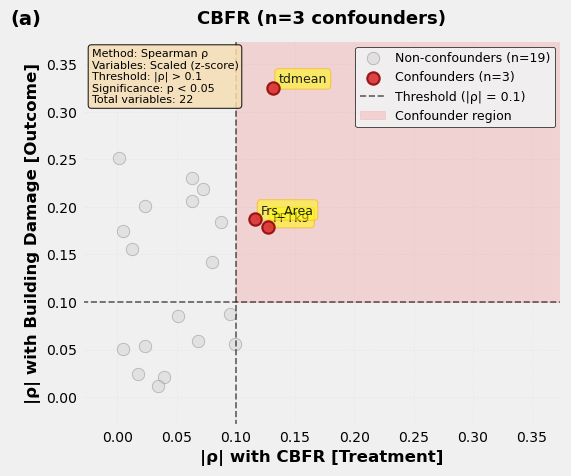


Creating plot for tdmean (panel b)...
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/b_tdmean_confounder_scaled.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/b_tdmean_confounder_scaled.pdf


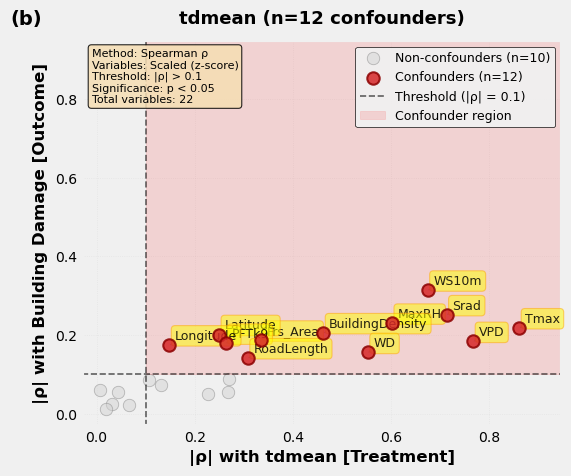


Creating plot for WS10m (panel c)...
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/c_WS10m_confounder_scaled.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/c_WS10m_confounder_scaled.pdf


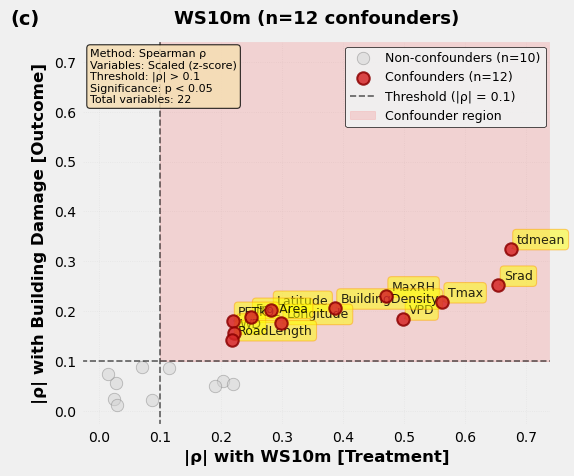


Creating plot for Slope (panel d)...
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/d_Slope_confounder_scaled.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/d_Slope_confounder_scaled.pdf


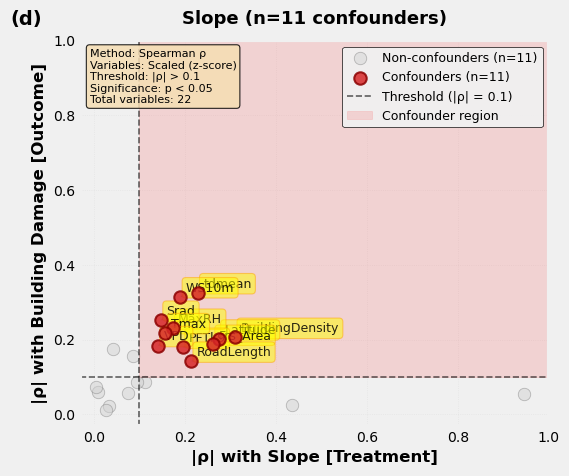


Creating plot for RoadLength (panel e)...
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/e_RoadLength_confounder_scaled.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/e_RoadLength_confounder_scaled.pdf


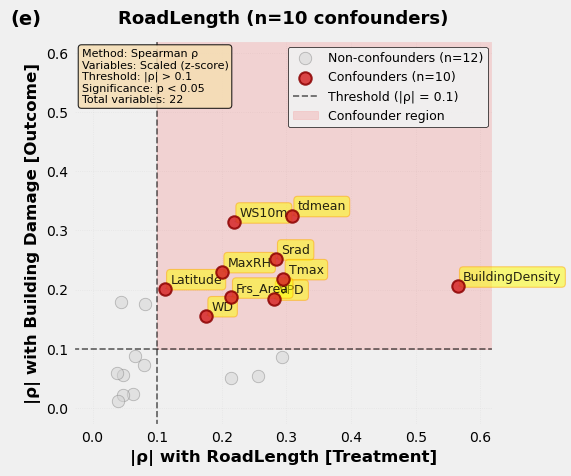


Creating plot for Elevation (panel f)...
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/f_Elevation_confounder_scaled.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/f_Elevation_confounder_scaled.pdf


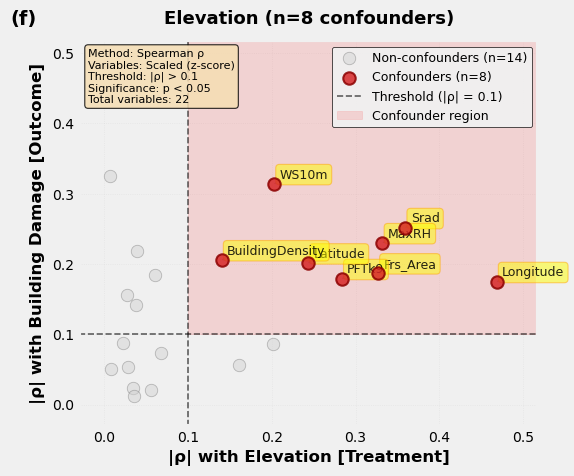


Creating plot for BuildingDensity (panel g)...
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/g_BuildingDensity_confounder_scaled.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/g_BuildingDensity_confounder_scaled.pdf


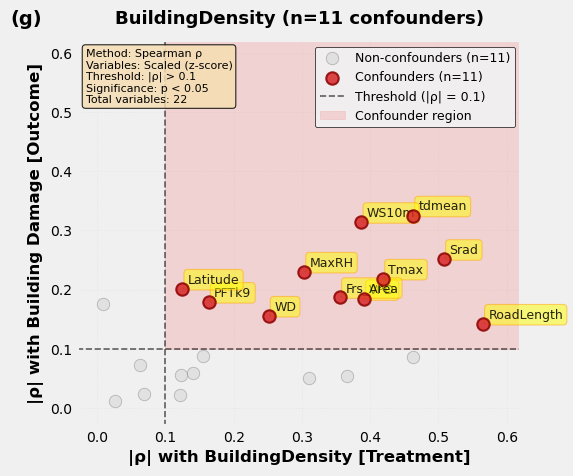


Creating plot for PFTk9 (panel h)...
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/h_PFTk9_confounder_scaled.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/h_PFTk9_confounder_scaled.pdf


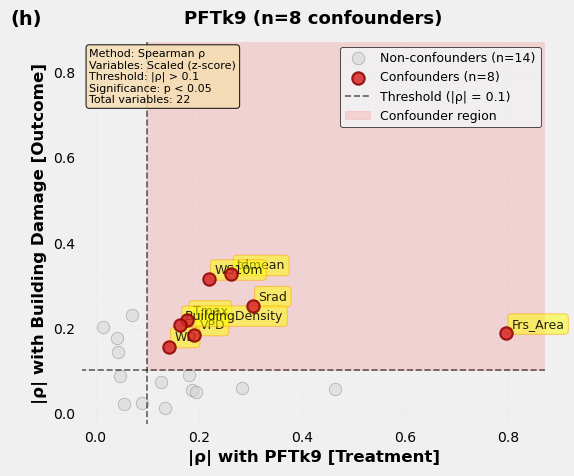


Creating plot for WUI_Area (panel i)...
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/i_WUI_Area_confounder_scaled.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/i_WUI_Area_confounder_scaled.pdf


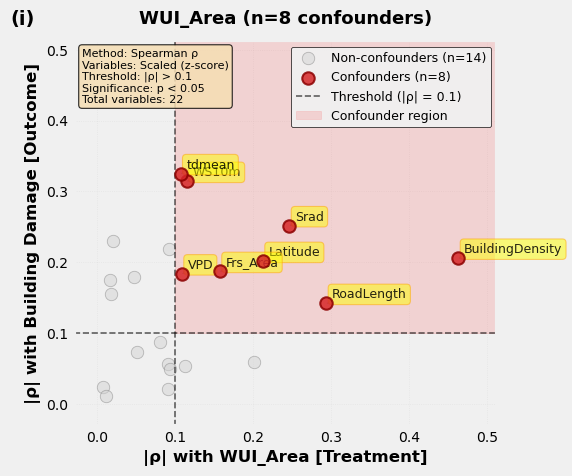


Creating plot for VPD (panel j)...
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/j_VPD_confounder_scaled.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/j_VPD_confounder_scaled.pdf


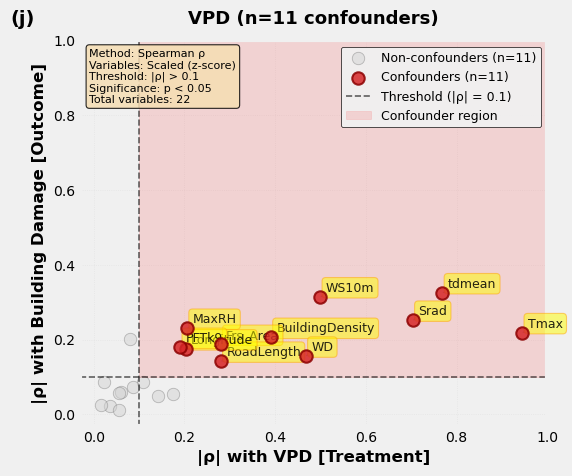


Creating plot for WD (panel k)...
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/k_WD_confounder_scaled.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/k_WD_confounder_scaled.pdf


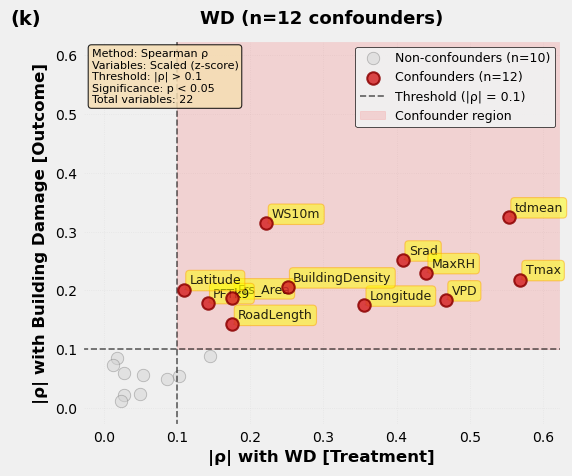


Creating plot for Tmax (panel l)...
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/l_Tmax_confounder_scaled.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/l_Tmax_confounder_scaled.pdf


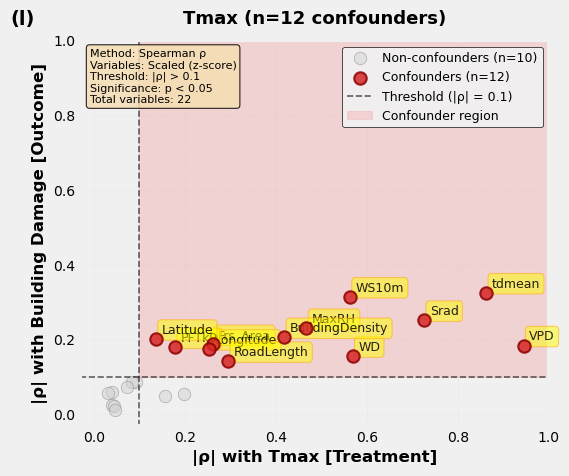


ALL INDIVIDUAL PLOTS CREATED (SCALED VERSION)
Location: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder//individual_plots/

CONFOUNDER LISTS SAVED (SCALED VERSION)
JSON file: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/Confounder/confounder_lists_scaled.json

SUMMARY FOR MANUSCRIPT (WITH SCALED VARIABLES)
(a) CBFR: 3 confounders - tdmean, PFTk9, Frs_Area
(b) tdmean: 12 confounders - WS10m, Tmax, Srad, VPD, MaxRH, BuildingDensity, WD, Frs_Area, Latitude, PFTk9, RoadLength, Longitude
(c) WS10m: 12 confounders - tdmean, Srad, Tmax, MaxRH, VPD, BuildingDensity, Latitude, Longitude, Frs_Area, PFTk9, WD, RoadLength
(d) Slope: 11 confounders - tdmean, BuildingDensity, WS10m, Latitude, Frs_Area, MaxRH, Srad, PFTk9, Tmax, RoadLength, VPD
(e) RoadLength: 10 confounders - BuildingDensity, tdmean, Srad, WS10m, Tmax, VPD, MaxRH, Frs_Area, WD, Latitude
(f) Elevation: 8 confounders - Srad, Longitude, MaxRH, WS10m, Frs_Area, PFT

In [9]:
# ==================== CONFOUNDER ASSESSMENT WITH SCALING ====================


# Define your treatments and potential confounders
treatments = ['CBFR', 'tdmean', 'WS10m',  'Slope', 'RoadLength', 
              'Elevation', 'BuildingDensity', 'PFTk9', 'WUI_Area', 'VPD', 'WD', 'Tmax']

outcome = 'Damage01'

# All variables (excluding outcome)
all_variables = ['Aspect', 'Elevation', 'Slope', 'TRI', 'EVH', 'EVT', 'WUI_Area',
                 'BuildingDensity', 'BTF', 'Frs_Area', 'RoadLength', 'PFTk9', 'CBFR',
                 'Longitude', 'Latitude',
                 'prcp', 'MaxRH', 'Srad', 'tdmean', 'WD', 'Tmax', 'VPD', 'WS10m']


def scale_variables(df, variables_to_scale):
    """
    Scale specified variables using StandardScaler.
    Returns a copy of the dataframe with scaled variables.
    """
    df_scaled = df.copy()
    scaler = StandardScaler()
    
    for var in variables_to_scale:
        if var in df_scaled.columns:
            # Handle missing values by scaling only non-missing values
            valid_mask = df_scaled[var].notna()
            if valid_mask.sum() > 0:
                df_scaled.loc[valid_mask, var] = scaler.fit_transform(
                    df_scaled.loc[valid_mask, [var]]
                ).flatten()
    
    return df_scaled


def assess_confounders_for_treatment(df, treatment, outcome, candidate_confounders,
                                     method='spearman', threshold=0.10, scale_treatment=True):
    """
    Assess confounder strength with 10% threshold.
    Now includes option to scale treatment variable.
    """
    results = []
    
    # Scale treatment variable if requested
    if scale_treatment:
        df_work = df.copy()
        scaler = StandardScaler()
        
        # Scale treatment variable
        valid_treatment = df_work[treatment].notna()
        if valid_treatment.sum() > 0:
            df_work.loc[valid_treatment, treatment] = scaler.fit_transform(
                df_work.loc[valid_treatment, [treatment]]
            ).flatten()
            
        # Also scale candidate confounders for fair comparison
        for var in candidate_confounders:
            if var in df_work.columns and df_work[var].dtype in ['float64', 'int64']:
                valid_var = df_work[var].notna()
                if valid_var.sum() > 0:
                    df_work.loc[valid_var, var] = scaler.fit_transform(
                        df_work.loc[valid_var, [var]]
                    ).flatten()
    else:
        df_work = df.copy()
    
    # Choose correlation method
    corr_func = spearmanr if method == 'spearman' else pearsonr
    
    for var in candidate_confounders:
        if var == treatment:  # Skip the treatment itself
            continue
            
        # Check for valid data
        valid_mask = df_work[[var, treatment, outcome]].notna().all(axis=1)
        if valid_mask.sum() < 100:
            continue
        
        df_valid = df_work[valid_mask]
        
        # Correlation with treatment (scaled)
        try:
            corr_t, p_t = corr_func(df_valid[var], df_valid[treatment])
        except:
            corr_t, p_t = 0, 1
        
        # Correlation with outcome (binary - not scaled)
        try:
            corr_y, p_y = corr_func(df_valid[var], df_valid[outcome])
        except:
            corr_y, p_y = 0, 1
        
        # Compute joint strength (product of absolute correlations)
        joint_strength = abs(corr_t) * abs(corr_y)
        
        # Classify as confounder with 10% threshold
        is_confounder = (abs(corr_t) > threshold and abs(corr_y) > threshold and 
                        p_t < 0.05 and p_y < 0.05)
        
        results.append({
            'variable': var,
            'corr_treatment': corr_t,
            'p_treatment': p_t,
            'corr_outcome': corr_y,
            'p_outcome': p_y,
            'abs_corr_treatment': abs(corr_t),
            'abs_corr_outcome': abs(corr_y),
            'joint_strength': joint_strength,
            'is_confounder': is_confounder
        })
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('joint_strength', ascending=False)
    
    return results_df


def plot_single_treatment_confounder(results_df, treatment, outcome, 
                                    panel_label='a',
                                    threshold=0.10,
                                    figsize=(6, 5),
                                    output_path=None,
                                    scaled=True):
    """
    Create a single high-quality scatter plot for one treatment.
    FIXED: xlim and ylim based on actual data range.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Separate confounders from non-confounders
    confounders = results_df[results_df['is_confounder']]
    non_confounders = results_df[~results_df['is_confounder']]
    
    # Plot non-confounders (gray)
    ax.scatter(non_confounders['abs_corr_treatment'], 
              non_confounders['abs_corr_outcome'],
              s=80, alpha=0.5, color='lightgray', 
              edgecolors='gray', linewidth=0.6,
              label=f'Non-confounders (n={len(non_confounders)})')
    
    # Plot confounders (red)
    ax.scatter(confounders['abs_corr_treatment'], 
              confounders['abs_corr_outcome'],
              s=80, alpha=0.85, color='#d62728',  # Red
              edgecolors='darkred', linewidth=1.5, zorder=5,
              label=f'Confounders (n={len(confounders)})')
    
    # Add threshold lines
    ax.axhline(threshold, color='black', linestyle='--', linewidth=1.2, 
               alpha=0.6, label=f'Threshold (|ρ| = {threshold})')
    ax.axvline(threshold, color='black', linestyle='--', linewidth=1.2, 
               alpha=0.6)
    
    # FIXED: Calculate actual data range for axis limits
    max_x = results_df['abs_corr_treatment'].max()
    max_y = results_df['abs_corr_outcome'].max()
    
    # Add padding (10% of the max value or at least 0.05)
    padding_x = max(0.05, max_x * 0.1)
    padding_y = max(0.05, max_y * 0.1)
    
    # Set limits based on actual data range (not capped at 1.0)
    xlim_max = min(max_x + padding_x, 1.0)  # Correlations can't exceed 1.0
    ylim_max = min(max_y + padding_y, 1.0)
    
    # Use the larger of the two for square aspect
    axis_max = max(xlim_max, ylim_max)
    
    # Shade the confounder region (up to actual max, not hardcoded 1.0)
    ax.fill_between([threshold, axis_max], threshold, axis_max, 
                    alpha=0.12, color='red', label='Confounder region')
    
    # Annotate ALL confounders (not just top ones)
    for _, row in confounders.iterrows():
        ax.annotate(row['variable'], 
                   (row['abs_corr_treatment'], row['abs_corr_outcome']),
                   fontsize=9, alpha=0.85, 
                   xytext=(4, 4), textcoords='offset points',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', 
                            alpha=0.5, edgecolor='orange', linewidth=0.8),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0',
                                 color='gray', lw=0.5, alpha=0.5))
    
    # Labels and title
    ax.set_xlabel(f'|ρ| with {treatment} [Treatment]', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'|ρ| with Building Damage [Outcome]', fontsize=12, fontweight='bold')
    
    # Panel label
    ax.text(-0.15, 1.08, f'({panel_label})', transform=ax.transAxes,
           fontsize=14, fontweight='bold', va='top')
    
    # Title with treatment name and confounder count
    ax.set_title(f'{treatment} (n={len(confounders)} confounders)', 
                fontsize=13, fontweight='bold', pad=12)
    
    # FIXED: Set axis limits based on data range
    ax.set_xlim(-0.03, axis_max)
    ax.set_ylim(-0.03, axis_max)
    
    # Grid
    ax.grid(alpha=0.3, linestyle=':', linewidth=0.6)
    ax.tick_params(labelsize=10)
    
    # Legend
    ax.legend(loc='best', fontsize=9, framealpha=0.95, edgecolor='black')
    
    # Add summary text box
    summary_text = (f'Method: Spearman ρ\n'
                   f'Variables: {"Scaled (z-score)" if scaled else "Original scale"}\n'
                   f'Threshold: |ρ| > {threshold}\n'
                   f'Significance: p < 0.05\n'
                   f'Total variables: {len(results_df)}')
    
    ax.text(0.02, 0.98, summary_text, transform=ax.transAxes,
           fontsize=8, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85,
                    edgecolor='black', linewidth=0.8))
    
    plt.tight_layout()
    
    if output_path:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        # Save as both PDF and SVG
        pdf_path = output_path.replace('.svg', '.pdf')
        fig.savefig(pdf_path, dpi=300, bbox_inches='tight', format='pdf')
        fig.savefig(output_path, dpi=300, bbox_inches='tight', format='svg')
        print(f"Saved: {output_path}")
        print(f"Saved: {pdf_path}")
    
    plt.show()
    plt.close()
    
    return fig


def analyze_all_treatments(df, treatments, outcome, all_variables,
                          output_dir='results/confounder_selection',
                          method='spearman', threshold=0.10, scale_treatment=True):
    """
    Run confounder assessment with 10% threshold and optional scaling.
    """
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(f'{output_dir}/individual_plots', exist_ok=True)
    
    all_results = {}
    summary_data = []
    
    # Print scaling status
    if scale_treatment:
        print("\n" + "="*80)
        print("SCALING: All treatment variables and confounders will be standardized (z-score)")
        print("="*80)
    
    for treatment in treatments:
        print(f"\n{'='*80}")
        print(f"Analyzing treatment: {treatment}")
        if scale_treatment:
            print(f"  -> Treatment will be scaled before correlation analysis")
        print(f"{'='*80}")
        
        # Get candidate confounders
        candidates = [v for v in all_variables if v != treatment]
        
        # Assess confounders with 10% threshold and scaling
        results_df = assess_confounders_for_treatment(
            df=df,
            treatment=treatment,
            outcome=outcome,
            candidate_confounders=candidates,
            method=method,
            threshold=threshold,
            scale_treatment=scale_treatment
        )
        
        # Store results
        all_results[treatment] = results_df
        
        # Save to CSV
        csv_path = f'{output_dir}/{treatment}_confounders_scaled.csv' if scale_treatment else f'{output_dir}/{treatment}_confounders.csv'
        results_df.to_csv(csv_path, index=False)
        print(f"Saved results to: {csv_path}")
        
        # Get confounders
        confounders = results_df[results_df['is_confounder']]['variable'].tolist()
        print(f"\nIdentified {len(confounders)} confounders (|ρ| > {threshold}):")
        print(confounders)
        
        # Summary statistics
        summary_data.append({
            'treatment': treatment,
            'n_candidates': len(candidates),
            'n_confounders': len(confounders),
            'confounders': ', '.join(confounders),
            'top_confounder': confounders[0] if confounders else 'None',
            'max_joint_strength': results_df['joint_strength'].max(),
            'scaled': scale_treatment
        })
    
    # Create summary table
    summary_df = pd.DataFrame(summary_data)
    summary_df = summary_df.sort_values('n_confounders', ascending=False)
    
    summary_path = f'{output_dir}/confounder_summary_scaled.csv' if scale_treatment else f'{output_dir}/confounder_summary.csv'
    summary_df.to_csv(summary_path, index=False)
    
    print(f"\n{'='*80}")
    print("SUMMARY OF ALL TREATMENTS" + (" (SCALED)" if scale_treatment else ""))
    print(f"{'='*80}")
    print(summary_df[['treatment', 'n_candidates', 'n_confounders', 'top_confounder']])
    
    return all_results, summary_df


def plot_all_individual_treatments(all_results, treatments, outcome, 
                                   threshold=0.10,
                                   output_dir=None,
                                   scaled=True):
    """
    Create individual plots for all treatments.
    FIXED: Handle missing output_dir parameter.
    """
    if output_dir is None:
        output_dir = 'results/confounder_selection'
    
    os.makedirs(f'{output_dir}/individual_plots', exist_ok=True)
    
    for idx, treatment in enumerate(treatments):
        panel_label = chr(97 + idx)  # a, b, c, ..., m, n (supports up to 26 treatments)
        
        print(f"\nCreating plot for {treatment} (panel {panel_label})...")
        
        results_df = all_results[treatment]
        
        suffix = '_scaled' if scaled else ''
        output_path = f'{output_dir}/individual_plots/{panel_label}_{treatment}_confounder{suffix}.svg'
        
        plot_single_treatment_confounder(
            results_df=results_df,
            treatment=treatment,
            outcome=outcome,
            panel_label=panel_label,
            threshold=threshold,
            figsize=(6, 5),
            output_path=output_path,
            scaled=scaled
        )
    
    print(f"\n{'='*80}")
    print("ALL INDIVIDUAL PLOTS CREATED" + (" (SCALED VERSION)" if scaled else ""))
    print(f"{'='*80}")
    print(f"Location: {output_dir}/individual_plots/")


# ==================== RUN ANALYSIS WITH SCALING ====================

# Step 1: Analyze all treatments with 10% threshold and SCALING
all_confounder_results, summary = analyze_all_treatments(
    df=Data_p,
    treatments=treatments,
    outcome='Damage01',
    all_variables=all_variables,
    output_dir=os.path.join(location, 'BuildingDamagePotential/MS/V03/CML/Confounder'),
    method='spearman',
    threshold=0.10,  # 10% threshold
    scale_treatment=True  # ENABLE SCALING
)

# Step 2: Create individual plots for each treatment
plot_all_individual_treatments(
    all_results=all_confounder_results,
    treatments=treatments,
    outcome='Damage01',
    threshold=0.10,
    output_dir=os.path.join(location, 'BuildingDamagePotential/MS/V03/CML/Confounder/'),
    scaled=True
)

# Step 3: Export confounder lists
confounder_dict = {}
for treatment in treatments:
    results_df = all_confounder_results[treatment]
    confounders = results_df[results_df['is_confounder']]['variable'].tolist()
    confounder_dict[treatment] = confounders

# Save as JSON (with scaled suffix)
json_path = os.path.join(location, 'BuildingDamagePotential/MS/V03/CML/Confounder/confounder_lists_scaled.json')
with open(json_path, 'w') as f:
    json.dump(confounder_dict, f, indent=2)

print(f"\n{'='*80}")
print("CONFOUNDER LISTS SAVED (SCALED VERSION)")
print(f"{'='*80}")
print(f"JSON file: {json_path}")

# Step 4: Print summary for manuscript
print(f"\n{'='*80}")
print("SUMMARY FOR MANUSCRIPT (WITH SCALED VARIABLES)")
print(f"{'='*80}")
for idx, treatment in enumerate(treatments):
    panel_label = chr(97 + idx)
    confounders = confounder_dict[treatment]
    print(f"({panel_label}) {treatment}: {len(confounders)} confounders - {', '.join(confounders)}")

# Optional: Compare scaled vs unscaled results
print(f"\n{'='*80}")
print("COMPARISON NOTE")
print(f"{'='*80}")
print("Scaling (standardization) ensures fair comparison between variables with different units.")
print("This is particularly important for:")
print("  - Temperature variables (Kelvin scale)")
print("  - Distance variables (meters vs kilometers)")
print("  - Density variables (different denominators)")
print("  - Environmental indices (different ranges)")

In [10]:
# ==================== LOAD CONFOUNDER LISTS FOR CML MODELING ====================
# Define your treatments
treatments = ['CBFR', 'tdmean', 'WS10m','Frs_Area','TRI', 'Slope','RoadLength', 'Elevation', 'BuildingDensity', 
              'PFTk9', 'WUI_Area', 'VPD', 'WD', 'Tmax']

outcome = 'Damage01'

# Load confounder lists (from previous analysis)
confounder_json_path = os.path.join(location,'BuildingDamagePotential/MS/V03/CML/Confounder/confounder_lists_scaled.json')
with open(confounder_json_path, 'r') as f:
    confounder_dict = json.load(f)


In [11]:
# Define your treatments and potential confounders
treatments = ['CBFR', 'tdmean', 'WS10m','Slope','RoadLength', 'Elevation', 'BuildingDensity', 
              'PFTk9', 'WUI_Area', 'VPD', 'WD', 'Tmax']

all_cate_rows = []


#  Normalization utility (same for all treatments)
def normalize_to_percentile(x):
    """
    Normalize array to 0–100 percentile scale
    """
    x = pd.Series(x)
    return 100 * (x.rank(method="average") - 1) / (len(x) - 1)

# Estimate CATEs for ONE treatment
def estimate_cate_only(df, treatment, outcome, confounders, random_state=42):
    """
    Estimate CATEs using CausalForestDML for one treatment
    """

    cols = [treatment, outcome] + confounders
    df_clean = df[cols].dropna().copy()
    df_clean.columns = df_clean.columns.astype(str)

    # Normalize treatment
    T = normalize_to_percentile(df_clean[treatment].values)

    # Normalize confounders
    X = np.column_stack([
        normalize_to_percentile(df_clean[c].values)
        for c in confounders
    ])

    # Outcome
    Y = df_clean[outcome].values

    # Causal Forest
    cf = CausalForestDML(
        n_estimators=500,
        min_samples_leaf=20,
        model_y=RandomForestRegressor(n_estimators=200, random_state=random_state),
        model_t=RandomForestRegressor(n_estimators=200, random_state=random_state),
        random_state=random_state,
        n_jobs=-1
    )

    cf.fit(Y, T, X=X)

    cate = cf.effect(X)
    ate = float(cf.ate(X))

    return cate, ate
# Run for ALL treatments and collect CATEs

all_cate_rows = []

for tr in treatments:
    # Check if the treatment exists in your confounder dictionary
    if tr not in confounder_dict:
        print(f"Skipping {tr}: No confounder list found in dictionary.")
        continue

    confounders = confounder_dict[tr]
    print(f"Processing {tr} with {len(confounders)} confounders")

    cate, ate = estimate_cate_only(
        df=Data_p,
        treatment=tr,
        outcome=outcome,
        confounders=confounders
    )

    for v in cate:
        all_cate_rows.append({
            "Treatment": tr,
            "CATE": v,
            "ATE": ate
        })

cate_df = pd.DataFrame(all_cate_rows)
cate_df.to_csv(os.path.join(location,'BuildingDamagePotential/MS/V03/CML/CATEs_scaled.csv'), index=False)
print("CATEs saved to CSV.")

Processing CBFR with 3 confounders


c:\Users\Somnath_UCI\anaconda3\envs\causalml\lib\site-packages\econml\utilities.py:644: UserWarning: Not all column names are strings. Coercing to strings for now.
  warnings.warn("Not all column names are strings. Coercing to strings for now.", UserWarning)


Processing tdmean with 12 confounders


c:\Users\Somnath_UCI\anaconda3\envs\causalml\lib\site-packages\econml\utilities.py:644: UserWarning: Not all column names are strings. Coercing to strings for now.
  warnings.warn("Not all column names are strings. Coercing to strings for now.", UserWarning)


Processing WS10m with 12 confounders


...

Processing WD with 12 confounders


c:\Users\Somnath_UCI\anaconda3\envs\causalml\lib\site-packages\econml\utilities.py:644: UserWarning: Not all column names are strings. Coercing to strings for now.
  warnings.warn("Not all column names are strings. Coercing to strings for now.", UserWarning)


Processing Tmax with 12 confounders


c:\Users\Somnath_UCI\anaconda3\envs\causalml\lib\site-packages\econml\utilities.py:644: UserWarning: Not all column names are strings. Coercing to strings for now.
  warnings.warn("Not all column names are strings. Coercing to strings for now.", UserWarning)


CATEs saved to CSV.


In [23]:
# ==================== ESTIMATE CATEs FOR ALL TREATMENTS ====================
cate_df = pd.read_csv(os.path.join(location,'BuildingDamagePotential/MS/V03/CML/CATEs_scaled.csv'))
cate_df.head()

,Treatment,CATE,ATE
0,CBFR,0.000833,0.000131
1,CBFR,0.000707,0.000131
2,CBFR,0.000263,0.000131
3,CBFR,0.000012,0.000131
4,CBFR,-0.000830,0.000131


In [24]:
#Sanity check: Mean CATE per treatment should match ATE
check = (
    cate_df
    .groupby("Treatment")
    .apply(lambda x: np.isclose(x["CATE"].mean(), x["ATE"].iloc[0], rtol=0.1))
)

print(check)

Treatment
BuildingDensity    True
CBFR               True
Elevation          True
PFTk9              True
RoadLength         True
Slope              True
Tmax               True
VPD                True
WD                 True
WS10m              True
WUI_Area           True
tdmean             True
dtype: bool


C:\Users\Somnath_UCI\AppData\Local\Temp\ipykernel_30056\190800859.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.isclose(x["CATE"].mean(), x["ATE"].iloc[0], rtol=0.1))


In [25]:
# Check unique treatment names
cate_df["Treatment"].unique()


array(['CBFR', 'tdmean', 'WS10m', 'Slope', 'RoadLength', 'Elevation',
       'BuildingDensity', 'PFTk9', 'WUI_Area', 'VPD', 'WD', 'Tmax'],
      dtype=object)

In [27]:
def plot_single_treatment_density(cate_df, treatment, output_dir='density_plots'):
    """
    Create individual density plot for a single treatment.
    Size: 3x3 inches for manuscript, PDF format.
    No titles, flexible limits based on data.
    """
    import os
    from scipy.stats import gaussian_kde
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Filter data
    treat_data = cate_df[cate_df["Treatment"] == treatment]["CATE"].values
    ate_val = cate_df[cate_df["Treatment"] == treatment]["ATE"].iloc[0]
    
    # Create figure - 3x3 inches
    fig, ax = plt.subplots(figsize=(2, 2))
    
    # Compute KDE
    kde = gaussian_kde(treat_data, bw_method='scott')
    
    # Flexible x-range based on data
    data_min = np.percentile(treat_data, 1)   # 1st percentile
    data_max = np.percentile(treat_data, 99)  # 99th percentile
    padding = (data_max - data_min) * 0.1     # 10% padding
    x_range = np.linspace(data_min - padding, data_max + padding, 500)
    
    density = kde(x_range)
    
    # Split into positive and negative regions
    positive_mask = x_range >= 0
    negative_mask = x_range < 0
    
    # Fill positive region (red)
    ax.fill_between(
        x_range[positive_mask],
        density[positive_mask],
        0,
        color='#E63946',
        alpha=0.6
    )
    
    # Fill negative region (blue)
    ax.fill_between(
        x_range[negative_mask],
        density[negative_mask],
        0,
        color='#2E86AB',
        alpha=0.6
    )
    
    # Outline
    ax.plot(x_range, density, color='black', linewidth=1.5, alpha=0.8)
    
    # ATE marker
    ate_density = kde(ate_val)[0]
    ax.plot(
        [ate_val, ate_val],
        [0, ate_density],
        color='red',
        linewidth=0.5,
        alpha=0.9,
        zorder=10
    )
    
    ax.plot(
        ate_val,
        ate_density,
        marker='*',
        markersize=4,
        color='red',
        markeredgecolor='black',
        markeredgewidth=1,
        zorder=11
    )
    
    # Zero reference line
    if data_min < 0 < data_max:  # Only if zero is in range
        ax.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.5)
    
    # Treatment label (small, bottom left)
    ax.text(
        0.02, 0.98,
        treatment,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=4,
        fontweight='normal',
        color='black',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                 edgecolor='black', alpha=0.8)
    )
    
    # ATE value (small, bottom right)
    ax.text(
        0.98, 0.98,
        f'ATE={ate_val:.4f}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=4,
        fontweight='normal',
        color='red',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                 edgecolor='red', alpha=0.8)
    )
    
    # Minimal labels
    ax.set_xlabel('CATE', fontsize=4, fontweight='normal')
    ax.set_ylabel('Density', fontsize=4, fontweight='normal')

    # Flexible limits
    ax.set_xlim(data_min - padding, data_max + padding)
    ax.set_ylim(0, density.max() * 1.05)
    
    # Clean up
    ax.tick_params(labelsize=7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Minimal grid
    ax.grid(axis='x', linestyle=':', alpha=0.3)
    
    # Tight layout
    plt.tight_layout()

    # Save as SVG
    output_path = os.path.join(output_dir, f'{treatment}_density.svg')
    fig.savefig(output_path, dpi=300, bbox_inches='tight', format='svg')
    print(f"Saved: {output_path}")
    
    plt.close(fig)  # Close to free memory
    
    return output_path


# Process all treatments
treatments = cate_df['Treatment'].unique()

print("Creating individual density plots...")
print("=" * 60)

for treatment in treatments:
    plot_single_treatment_density(cate_df, treatment, output_dir=os.path.join(location,'BuildingDamagePotential/MS/V03/CML/density_plots/'))

print("=" * 60)
print(f"✓ Created {len(treatments)} density plots in 'density_plots/' directory")

Creating individual density plots...
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/density_plots/CBFR_density.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/density_plots/tdmean_density.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/density_plots/WS10m_density.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/density_plots/Slope_density.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/density_plots/RoadLength_density.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/density_plots/Elevation_density.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/density_plots/BuildingDensity_density.svg
Saved: C:\Users\Somnath_UCI\OneDrive - UC Irvine\BuildingDamagePotential/MS/V03/CML/density_plots/PFTk9_density.svg
Saved: C:\Users\

In [28]:
# ==================== ESTIMATE CATEs WITH METADATA ====================
def flatten_confounders(confounders):
    """
    Expand confounders into a flat list of column names
    """
    flat = []

    for c in confounders:

        # Case 1: list / tuple / np.ndarray / pandas Index
        if isinstance(c, (list, tuple, np.ndarray, pd.Index)):
            for sub_c in c:
                flat.append(str(sub_c))

        # Case 2: string that looks like a list
        elif isinstance(c, str) and c.startswith("[") and c.endswith("]"):
            parsed = eval(c)  # safe here, controlled input
            for sub_c in parsed:
                flat.append(str(sub_c))

        # Case 3: normal single column
        else:
            flat.append(str(c))

    return flat

def normalize_to_percentile(x):
    x = np.asarray(x)

    if x.ndim != 1:
        raise ValueError(f"normalize_to_percentile expects 1D array, got shape {x.shape}")

    x = pd.Series(x)
    return 100 * (x.rank(method="average") - 1) / (len(x) - 1)

# CATE along Fires and Spatial scale 

def estimate_cate_only(df, treatment, outcome, confounders, random_state=42):

    meta_cols = ["Firename", "Longitude", "Latitude"]
    
    flat_confounders = sorted(set(flatten_confounders(confounders)))

    cols = set([treatment, outcome] + meta_cols)
    cols.update(flat_confounders)
    cols = list(cols)

    df_clean = df[cols].dropna().copy()
    df_clean.columns = df_clean.columns.astype(str)

    # Sanity checks
    missing = set(flat_confounders) - set(df_clean.columns)
    if missing:
        raise KeyError(f"Missing confounder columns: {missing}")

    # Treatment
    T = normalize_to_percentile(df_clean[treatment].values)

    # Confounders
    X_list = []
    for c in flat_confounders:
        arr = df_clean[c].values
        if arr.ndim != 1:
            raise RuntimeError(f"Confounder '{c}' not 1D: {arr.shape}")
        X_list.append(normalize_to_percentile(arr))

    X = np.column_stack(X_list)

    # Outcome
    Y = df_clean[outcome].values

    assert X.shape[0] == len(T) == len(Y)

    cf = CausalForestDML(
        n_estimators=500,
        min_samples_leaf=20,
        model_y=RandomForestRegressor(n_estimators=200, random_state=random_state),
        model_t=RandomForestRegressor(n_estimators=200, random_state=random_state),
        random_state=random_state,
        n_jobs=-1
    )


    cf.fit(Y, T, X=X)

    cate = cf.effect(X)
    ate = float(cf.ate(X))

    print(
        f"[{treatment}] n={len(df_clean)}, "
        f"X_dim={X.shape[1]}, "
        f"ATE={ate:.4f}"
    )

    meta_df = df_clean[meta_cols].reset_index(drop=True)

    return cate, ate, meta_df


all_cate_rows = []

for tr in treatments:

    if tr not in confounder_dict:
        print(f"Skipping {tr}: No confounder list found.")
        continue

    confounders = confounder_dict[tr]
    print(f"Processing {tr} with {len(confounders)} confounders")

    cate, ate, meta_df = estimate_cate_only(
        df=Data_p,
        treatment=tr,
        outcome=outcome,
        confounders=confounders
    )

    for i in range(len(cate)):
        all_cate_rows.append({
            "Treatment": tr,
            "CATE": cate[i],
            "ATE": ate,
            "Firename": meta_df.loc[i, "Firename"],
            "Longitude": meta_df.loc[i, "Longitude"],
            "Latitude": meta_df.loc[i, "Latitude"]
        })

cate_df = pd.DataFrame(all_cate_rows)
cate_df.to_csv(os.path.join(location,'BuildingDamagePotential/MS/V03/CML/CATEs_with_metadata_scaled.csv'), index=False)
print("CATEs with metadata saved to CSV.")

Processing CBFR with 3 confounders


c:\Users\Somnath_UCI\anaconda3\envs\causalml\lib\site-packages\econml\utilities.py:644: UserWarning: Not all column names are strings. Coercing to strings for now.
  warnings.warn("Not all column names are strings. Coercing to strings for now.", UserWarning)


[CBFR] n=97746, X_dim=3, ATE=0.0001
Processing tdmean with 12 confounders


c:\Users\Somnath_UCI\anaconda3\envs\causalml\lib\site-packages\econml\utilities.py:644: UserWarning: Not all column names are strings. Coercing to strings for now.
  warnings.warn("Not all column names are strings. Coercing to strings for now.", UserWarning)


[tdmean] n=97746, X_dim=12, ATE=-0.0038
Processing WS10m with 12 confounders


...

[VPD] n=97746, X_dim=11, ATE=0.0161
Processing WD with 12 confounders


c:\Users\Somnath_UCI\anaconda3\envs\causalml\lib\site-packages\econml\utilities.py:644: UserWarning: Not all column names are strings. Coercing to strings for now.
  warnings.warn("Not all column names are strings. Coercing to strings for now.", UserWarning)


[WD] n=97746, X_dim=12, ATE=-0.0022
Processing Tmax with 12 confounders


c:\Users\Somnath_UCI\anaconda3\envs\causalml\lib\site-packages\econml\utilities.py:644: UserWarning: Not all column names are strings. Coercing to strings for now.
  warnings.warn("Not all column names are strings. Coercing to strings for now.", UserWarning)


[Tmax] n=97746, X_dim=12, ATE=0.0075
CATEs with metadata saved to CSV.


In [29]:
# ==================== ESTIMATE CATEs FOR ALL TREATMENTS ====================
cate_df = pd.read_csv(os.path.join(location,'BuildingDamagePotential/MS/V03/CML/CATEs_with_metadata_scaled.csv'))
cate_df.head()

,Treatment,CATE,ATE,Firename,Longitude,Latitude
0,CBFR,0.000729,0.000131,Quail,-122.044465,38.474960
1,CBFR,0.000587,0.000131,Quail,-122.043252,38.477442
2,CBFR,0.000184,0.000131,Quail,-122.044585,38.479358
3,CBFR,-0.000031,0.000131,Quail,-122.015115,38.487313
4,CBFR,-0.000828,0.000131,Quail,-122.016122,38.485636


In [30]:
FireWise = cate_df.groupby(["Firename", "Treatment"])["CATE"].mean()
FireWise.index.get_level_values("Firename").unique()

Index(['August Complex North', 'August Complex South', 'August Complex West',
       'Bear', 'CZU Lightning Complex', 'Carmel', 'Castle', 'Doe', 'Elkhorn',
       'Hennessey', 'Lassen', 'Mendocino Complex', 'Meyers', 'Napa',
       'No Fire Name Found', 'Quail', 'River', 'SCU Lightning Complex',
       'Santa Rosa', 'Sonoma', 'St. Helena', 'Walbridge', 'Wind Complex'],
      dtype='object', name='Firename')

In [31]:
cate_df

,Treatment,CATE,ATE,Firename,Longitude,Latitude
0,CBFR,0.000729,0.000131,Quail,-122.044465,38.474960
1,CBFR,0.000587,0.000131,Quail,-122.043252,38.477442
2,CBFR,0.000184,0.000131,Quail,-122.044585,38.479358
3,CBFR,-0.000031,0.000131,Quail,-122.015115,38.487313
4,CBFR,-0.000828,0.000131,Quail,-122.016122,38.485636
...,...,...,...,...,...,...
1172947,Tmax,-0.011185,0.007534,No Fire Name Found,-118.700625,34.033408
1172948,Tmax,-0.010843,0.007534,No Fire Name Found,-118.700902,34.033278
1172949,Tmax,-0.010848,0.007534,No Fire Name Found,-118.701102,34.033618
1172950,Tmax,0.010865,0.007534,No Fire Name Found,-118.698270,34.032085


In [32]:
# Convert to GeoDataFrame for spatial analysis
gdf = gpd.GeoDataFrame(
    cate_df,
    geometry=gpd.points_from_xy(cate_df.Longitude, cate_df.Latitude),
    crs="EPSG:4326"
)
gdf

,Treatment,CATE,ATE,Firename,Longitude,Latitude,geometry
0,CBFR,0.000729,0.000131,Quail,-122.044465,38.474960,POINT (-122.04446 38.47496)
1,CBFR,0.000587,0.000131,Quail,-122.043252,38.477442,POINT (-122.04325 38.47744)
2,CBFR,0.000184,0.000131,Quail,-122.044585,38.479358,POINT (-122.04458 38.47936)
3,CBFR,-0.000031,0.000131,Quail,-122.015115,38.487313,POINT (-122.01512 38.48731)
4,CBFR,-0.000828,0.000131,Quail,-122.016122,38.485636,POINT (-122.01612 38.48564)
...,...,...,...,...,...,...,...
1172947,Tmax,-0.011185,0.007534,No Fire Name Found,-118.700625,34.033408,POINT (-118.70062 34.03341)
1172948,Tmax,-0.010843,0.007534,No Fire Name Found,-118.700902,34.033278,POINT (-118.7009 34.03328)
1172949,Tmax,-0.010848,0.007534,No Fire Name Found,-118.701102,34.033618,POINT (-118.7011 34.03362)
1172950,Tmax,0.010865,0.007534,No Fire Name Found,-118.698270,34.032085,POINT (-118.69827 34.03208)


Creating 3x3 inch individual maps...
[1/13] CBFR... ✓ Saved: CBFR_hexbin.svg


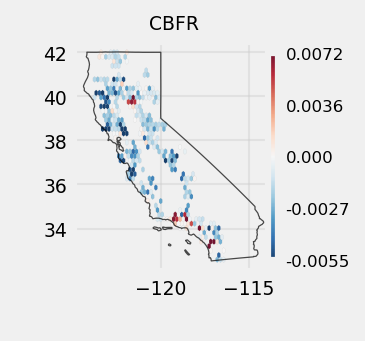

[2/13] tdmean... ✓ Saved: tdmean_hexbin.svg


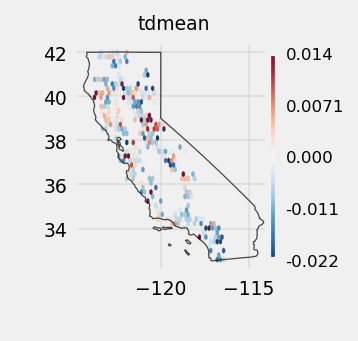

[3/13] WS10m... ✓ Saved: WS10m_hexbin.svg


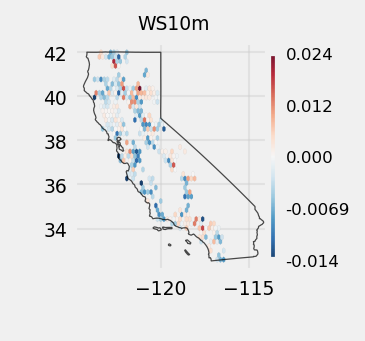

[4/13] Slope... ✓ Saved: Slope_hexbin.svg


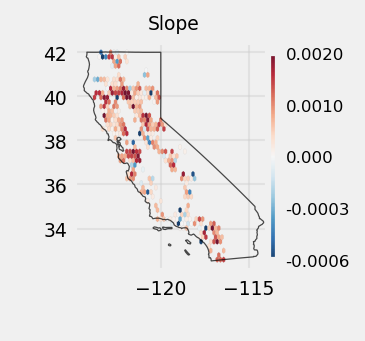

[5/13] Elevation... ✓ Saved: Elevation_hexbin.svg


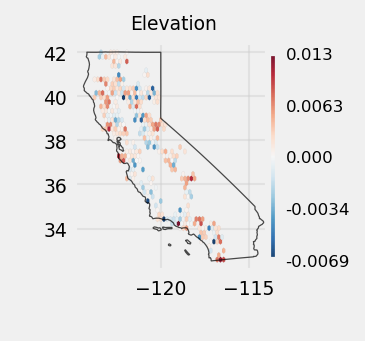

[6/13] BuildingDensity... ✓ Saved: BuildingDensity_hexbin.svg


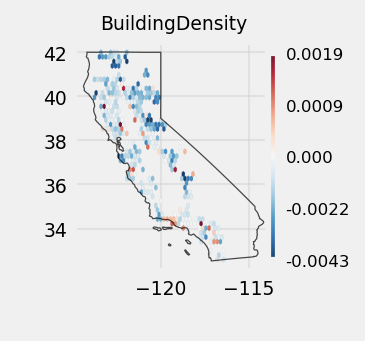

[7/13] PFTk9... ✓ Saved: PFTk9_hexbin.svg


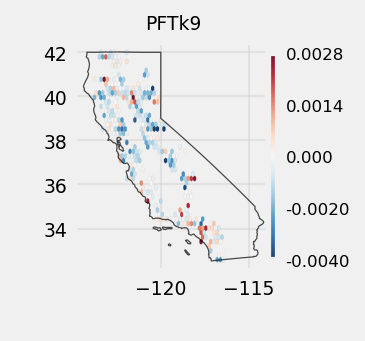

[8/13] WUI_Area... ✓ Saved: WUI_Area_hexbin.svg


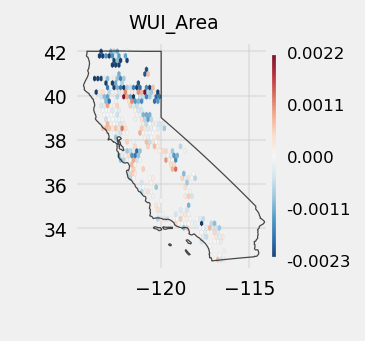

[9/13] WD... ✓ Saved: WD_hexbin.svg


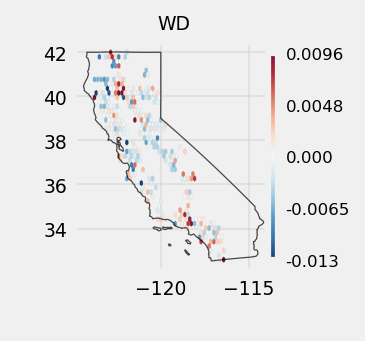

[10/13] RoadLength... ✓ Saved: RoadLength_hexbin.svg


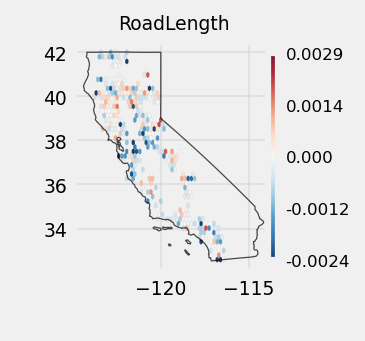

[11/13] Tmax... ✓ Saved: Tmax_hexbin.svg


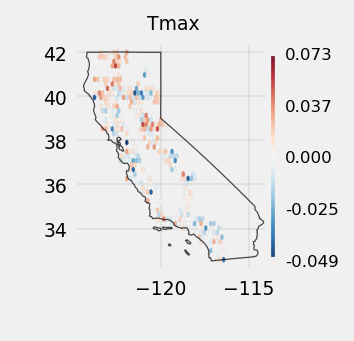

[12/13] MaxRH... No data for MaxRH
[13/13] VPD... ✓ Saved: VPD_hexbin.svg


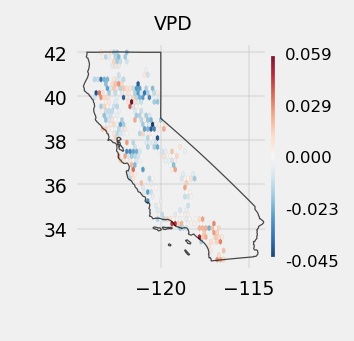

✓ All maps created!


In [33]:
# ==================== PLOT 3x3 INCH HEXBIN MAPS ====================

def plot_treatment_3x3(gdf, treatment, gridsize=40, output_dir=None):
    """
    3x3 inch hexbin map - ensures ticks on both + and - sides.
    No scientific notation for better readability.
    """
    fig, ax = plt.subplots(figsize=(2.5, 2.5), dpi=150)
    
    # California boundary
    try:
        url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip"
        states = gpd.read_file(url)
        ca = states[states['NAME'] == 'California']
    except:
        ca = None
    
    gdf_treat = gdf[gdf['Treatment'] == treatment]
    
    if len(gdf_treat) == 0:
        print(f"No data for {treatment}")
        plt.close(fig)
        return None
    
    ate_val = gdf_treat['ATE'].iloc[0]
    
    # 10-90 percentile range
    vmin = gdf_treat['CATE'].quantile(0.1)
    vmax = gdf_treat['CATE'].quantile(0.9)
    
    # Ensure we have actual range (not zero)
    if abs(vmin) < 1e-10:
        vmin = gdf_treat['CATE'].min()
    if abs(vmax) < 1e-10:
        vmax = gdf_treat['CATE'].max()
    
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    
    # Hexbin: grey thin edges
    hexbin = ax.hexbin(
        gdf_treat.geometry.x,
        gdf_treat.geometry.y,
        C=gdf_treat['CATE'],
        gridsize=gridsize,
        cmap='RdBu_r',
        norm=norm,
        reduce_C_function=np.mean,
        mincnt=1,
        edgecolors='grey',
        linewidths=0.03,
        alpha=0.92
    )
    
    # State boundary
    if ca is not None:
        ca.boundary.plot(ax=ax, edgecolor='black', linewidth=0.6, alpha=0.7)
    
    # Colorbar: with 5 ticks (guaranteed both sides)
    cbar = plt.colorbar(hexbin, ax=ax, pad=-0.02, shrink=0.9)
    
    # Create 5 evenly spaced ticks: min, mid-, 0, mid+, max
    tick_values = np.array([vmin, vmin/2, 0, vmax/2, vmax])
    cbar.set_ticks(tick_values)
    cbar.ax.tick_params(labelsize=8)
    
    # Format WITHOUT scientific notation - use fixed decimal places
    tick_labels = []
    for val in tick_values:
        if abs(val) < 0.0001:
            tick_labels.append('0.000')  # Treat very small as zero
        elif abs(val) < 0.001:
            tick_labels.append(f'{val:.4f}')  # 4 decimal places
        elif abs(val) < 0.01:
            tick_labels.append(f'{val:.4f}')  # 4 decimal places
        elif abs(val) < 0.1:
            tick_labels.append(f'{val:.3f}')  # 3 decimal places
        elif abs(val) < 1:
            tick_labels.append(f'{val:.3f}')  # 3 decimal places
        elif abs(val) < 10:
            tick_labels.append(f'{val:.2f}')  # 2 decimal places
        elif abs(val) < 100:
            tick_labels.append(f'{val:.2f}')  # 2 decimal places
        else:
            tick_labels.append(f'{val:.1f}')  # 1 decimal place
    
    cbar.set_ticklabels(tick_labels)
    
    # Title
    ax.set_title(f'{treatment}', 
                fontsize=9, fontweight='normal', pad=6)
    
    ax.set_xlabel(' ', fontsize=10)
    ax.set_ylabel(' ', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(True, alpha=0.4)
    
    plt.tight_layout()
    
    # Save
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, f'{treatment}_hexbin.svg')
        fig.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved: {treatment}_hexbin.svg")

    plt.show()
    plt.close(fig)
    return fig


# Run for all treatments
treatments = ['CBFR', 'tdmean', 'WS10m', 'Slope', 'Elevation', 
              'BuildingDensity', 'PFTk9', 'WUI_Area', 'WD', 
              'RoadLength', 'Tmax', 'MaxRH', 'VPD']

output_dir = os.path.join(location, 'BuildingDamagePotential/MS/V03/CML/Spatial')

print("Creating 3x3 inch individual maps...")
print("=" * 60)

for i, treatment in enumerate(treatments, 1):
    print(f"[{i}/{len(treatments)}] {treatment}...", end=' ')
    plot_treatment_3x3(gdf, treatment, gridsize=40, output_dir=output_dir)

print("=" * 60)
print("✓ All maps created!")

In [36]:
from scipy import stats

Creating spatial maps with density curves (FIXED VERSION)...
[1/13] CBFR... ✓ Saved: CBFR_spatial_density.svg


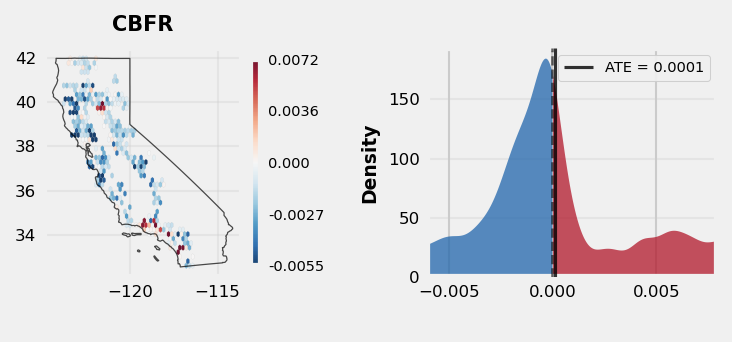

[2/13] tdmean... ✓ Saved: tdmean_spatial_density.svg


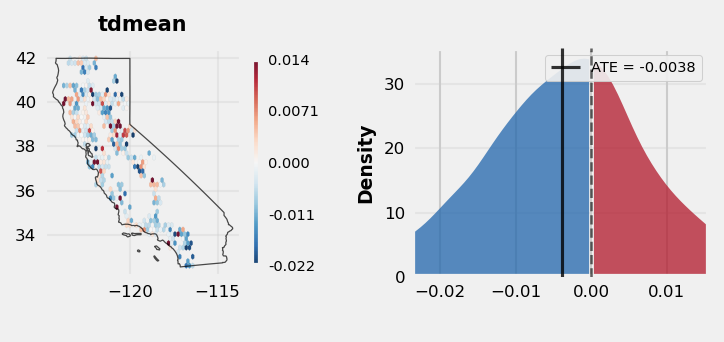

[3/13] WS10m... ✓ Saved: WS10m_spatial_density.svg


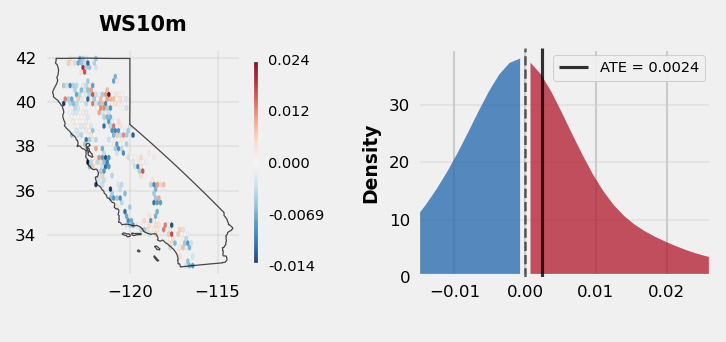

[4/13] Slope... ✓ Saved: Slope_spatial_density.svg


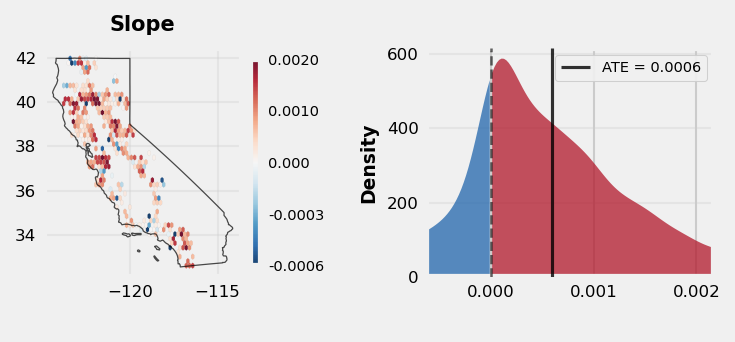

[5/13] Elevation... ✓ Saved: Elevation_spatial_density.svg


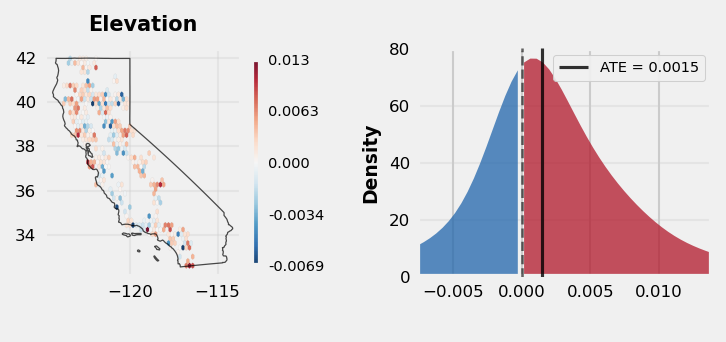

[6/13] BuildingDensity... ✓ Saved: BuildingDensity_spatial_density.svg


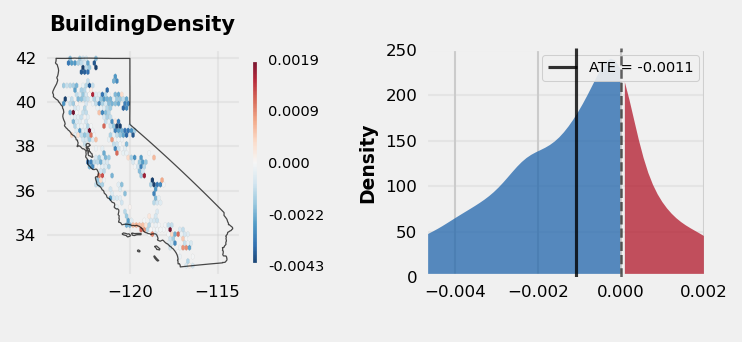

[7/13] PFTk9... ✓ Saved: PFTk9_spatial_density.svg


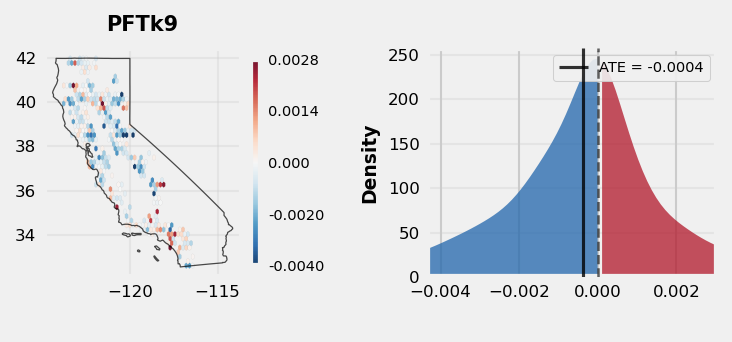

[8/13] WUI_Area... ✓ Saved: WUI_Area_spatial_density.svg


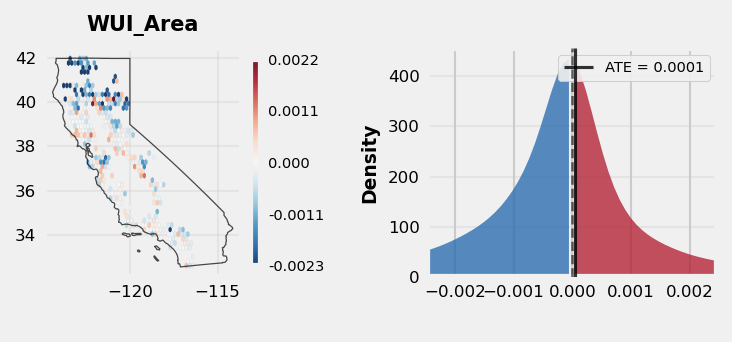

[9/13] WD... ✓ Saved: WD_spatial_density.svg


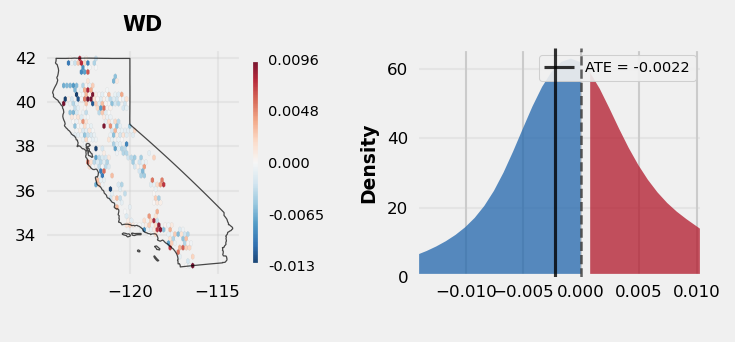

[10/13] RoadLength... ✓ Saved: RoadLength_spatial_density.svg


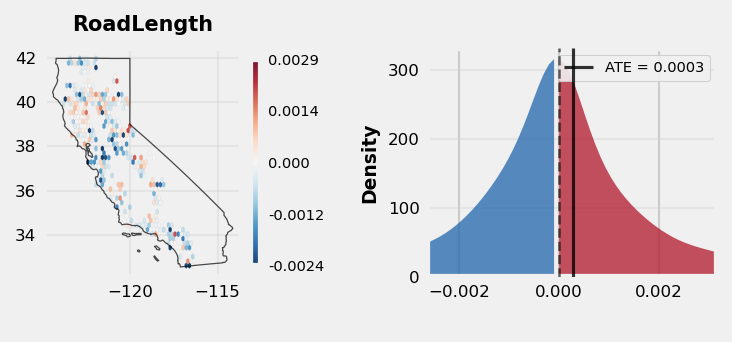

[11/13] Tmax... ✓ Saved: Tmax_spatial_density.svg


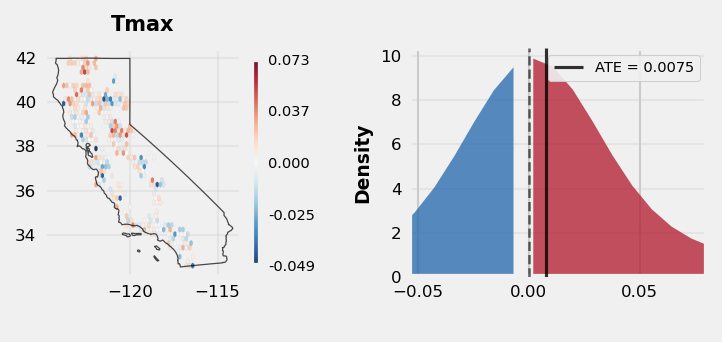

[12/13] MaxRH... No data for MaxRH
[13/13] VPD... ✓ Saved: VPD_spatial_density.svg


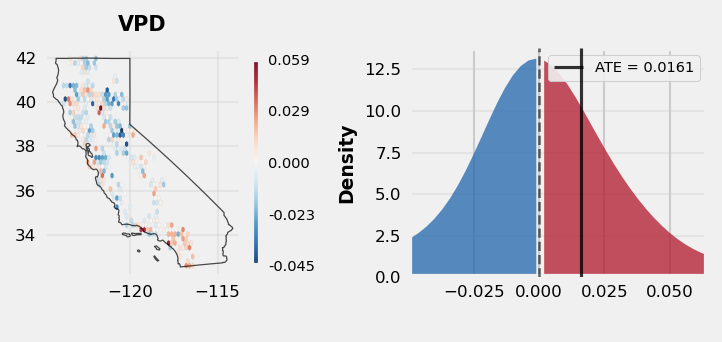

✓ All combined maps created!


In [39]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
import os

# ==================== FIXED: NO WHITE GAP + TRANSPARENT LABEL ====================

def plot_treatment_with_density(gdf, treatment, gridsize=40, output_dir=None):
    """
    Creates a combined figure with:
    - Left panel: Spatial hexbin CATE map
    - Right panel: Density curve with blue (negative) and red (positive) sections
    FIXED: No white gap at zero, transparent CATE label
    """
    fig, (ax_map, ax_density) = plt.subplots(1, 2, figsize=(6, 2.5), dpi=150,
                                              gridspec_kw={'width_ratios': [1.2, 0.8]})
    
    # ========== LEFT PANEL: SPATIAL MAP ==========
    try:
        url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_20m.zip"
        states = gpd.read_file(url)
        ca = states[states['NAME'] == 'California']
    except:
        ca = None
    
    gdf_treat = gdf[gdf['Treatment'] == treatment]
    
    if len(gdf_treat) == 0:
        print(f"No data for {treatment}")
        plt.close(fig)
        return None
    
    ate_val = gdf_treat['ATE'].iloc[0]
    cate_values = gdf_treat['CATE'].values
    
    # 10-90 percentile range for colormap
    vmin = gdf_treat['CATE'].quantile(0.1)
    vmax = gdf_treat['CATE'].quantile(0.9)
    
    if abs(vmin) < 1e-10:
        vmin = gdf_treat['CATE'].min()
    if abs(vmax) < 1e-10:
        vmax = gdf_treat['CATE'].max()
    
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    
    # Hexbin
    hexbin = ax_map.hexbin(
        gdf_treat.geometry.x,
        gdf_treat.geometry.y,
        C=gdf_treat['CATE'],
        gridsize=gridsize,
        cmap='RdBu_r',
        norm=norm,
        reduce_C_function=np.mean,
        mincnt=1,
        edgecolors='grey',
        linewidths=0.03,
        alpha=0.92
    )
    
    if ca is not None:
        ca.boundary.plot(ax=ax_map, edgecolor='black', linewidth=0.6, alpha=0.7)
    
    # Colorbar
    cbar = plt.colorbar(hexbin, ax=ax_map, pad=0.02, shrink=0.9)
    tick_values = np.array([vmin, vmin/2, 0, vmax/2, vmax])
    cbar.set_ticks(tick_values)
    cbar.ax.tick_params(labelsize=7)
    
    tick_labels = []
    for val in tick_values:
        if abs(val) < 0.0001:
            tick_labels.append('0.000')
        elif abs(val) < 0.01:
            tick_labels.append(f'{val:.4f}')
        elif abs(val) < 0.1:
            tick_labels.append(f'{val:.3f}')
        else:
            tick_labels.append(f'{val:.2f}')
    
    cbar.set_ticklabels(tick_labels)
    
    ax_map.set_title(f'{treatment}', fontsize=10, fontweight='bold', pad=8)
    ax_map.set_xlabel('')
    ax_map.set_ylabel('')
    ax_map.tick_params(labelsize=8)
    ax_map.grid(True, alpha=0.3)
    
    # ========== RIGHT PANEL: DENSITY CURVE (FIXED) ==========
    
    # Compute kernel density estimation
    kde = stats.gaussian_kde(cate_values)
    x_range = np.linspace(cate_values.min(), cate_values.max(), 1000)  # ← INCREASED from 500 to 1000
    density = kde(x_range)
    
    # FIX 1: Use <= 0 for negative to ensure overlap at zero
    negative_mask = x_range <= 0  # ← Changed from < to <=
    positive_mask = x_range >= 0
    
    # Plot negative (blue) - plot first so it's behind
    ax_density.fill_between(x_range[negative_mask], 0, density[negative_mask], 
                            color='#2166ac', alpha=0.75, edgecolor='none')  # ← Added edgecolor='none'
    
    # Plot positive (red) - overlaps at zero to eliminate gap
    ax_density.fill_between(x_range[positive_mask], 0, density[positive_mask], 
                            color='#b2182b', alpha=0.75, edgecolor='none')  # ← Added edgecolor='none'
    
    # Add vertical line at zero (on top)
    ax_density.axvline(x=0, color='black', linestyle='--', linewidth=1.2, alpha=0.6, zorder=10)
    
    # Add ATE line
    ax_density.axvline(x=ate_val, color='black', linestyle='-', linewidth=1.5, 
                      alpha=0.8, label=f'ATE = {ate_val:.4f}', zorder=10)
    
    # FIX 2: Make CATE label transparent (invisible) or remove it
    # Option A: Invisible label
    ax_density.set_xlabel('CATE', fontsize=9, fontweight='bold', alpha=0.0)  # ← alpha=0.0 makes it invisible
    
    # Option B: Remove label entirely (uncomment this and comment above line)
    # ax_density.set_xlabel('')
    
    ax_density.set_ylabel('Density', fontsize=9, fontweight='bold')
    ax_density.tick_params(labelsize=8)
    ax_density.grid(True, alpha=0.3, axis='y')
    ax_density.legend(fontsize=7, loc='upper right', framealpha=0.9)
    
    # Set x-axis limits to match colorbar range
    ax_density.set_xlim(vmin * 1.1, vmax * 1.1)
    
    # Set y-axis to start from 0
    ax_density.set_ylim(bottom=0)  # ← Ensures density starts at 0
    
    plt.tight_layout()
    
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, f'{treatment}_spatial_density.svg')
        fig.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved: {treatment}_spatial_density.svg")
    
    plt.show()
    plt.close(fig)
    return fig


# ==================== RUN FOR ALL TREATMENTS ====================

treatments = ['CBFR', 'tdmean', 'WS10m', 'Slope', 'Elevation', 
              'BuildingDensity', 'PFTk9', 'WUI_Area', 'WD', 
              'RoadLength', 'Tmax', 'MaxRH', 'VPD']

output_dir = os.path.join(location, 'BuildingDamagePotential/MS/V03/CML/Spatial')

print("Creating spatial maps with density curves (FIXED VERSION)...")
print("=" * 60)

for i, treatment in enumerate(treatments, 1):
    print(f"[{i}/{len(treatments)}] {treatment}...", end=' ')
    plot_treatment_with_density(gdf, treatment, gridsize=40, output_dir=output_dir)

print("=" * 60)
print("✓ All combined maps created!")